In [30]:
# %pip install datasets
# %pip install lightning
# %pip install -U tensorboard

In [31]:

from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

In [32]:
from datasets import load_dataset, Dataset, Image as Img
from IPython.display import Image, clear_output
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import io
from model import PointLiteNet
from torch.utils.data import DataLoader
from IPython.display import clear_output
import random


device = "cuda" if torch.cuda.is_available() else "cpu"

print("using device: ", device)


NUM_POINTS = 200

using device:  cuda


In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x) * 200 - 100
    amount = amount.view(-1, 1, 1)  # sort shape so broadcasting works
    return x * (1 - amount) + noise * amount

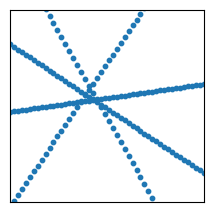

In [35]:


def plot_data(data):
    my_dpi = 100
    fig, ax = plt.subplots(frameon=False, figsize=(250/my_dpi, 250/my_dpi), dpi=my_dpi)
    ax.scatter(data[0], data[1], s=10)
    ax.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False) 
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.autoscale(tight=True)
    ax.set_ylim(-100, 100)
    return fig


def generate_data(num_points, lines_count):
    out = None
    for i in range(lines_count):
        x = torch.linspace(-100, 100, num_points//lines_count)
        k = random.random()*4 - 2
        n = random.randint(-50, 50)
        y = k * x + n
        # noise = torch.rand_like(y)
        # y = y * (1 - amount) + noise * amount
        if(out == None):
            out = torch.vstack((x,y))
        else:
            out = torch.hstack((out,torch.vstack((x,y))))
    return out

data = generate_data(NUM_POINTS, 4)
fig = plot_data(data)
fig.show()


torch.Size([2, 200]) <class 'torch.Tensor'>


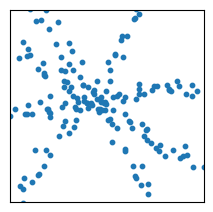

In [36]:
print(data.shape, type(data))

plot_data(corrupt(data.unsqueeze(0), torch.ones(data.shape).unsqueeze(0)*0.1)[0]).show()

In [37]:
def gen_plot():
    """Create a pyplot plot and save to buffer."""
    buf = io.BytesIO()
    plt.savefig(buf, format='jpeg')
    buf.seek(0)
    return buf

In [38]:
from typing import List


class PointsDataset(Dataset):
    def __init__(self, num_points:int, num_lines:int):
        self.num_points = num_points
        self.num_lines = num_lines
        
    def __len__(self):
        return 5000

    def __getitem__(self, idx):
        item = torch.vstack([generate_data(num_points=self.num_points, lines_count=self.num_lines) for i in idx])
        return item
    
    def __getitems__(self, keys: List) -> List:
        return [generate_data(num_points=self.num_points, lines_count=self.num_lines) for i in keys]

train_dataset = PointsDataset(NUM_POINTS, 4)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=64)

In [39]:
def get_generator_figure(net):
    # Fetch some data
    x = next(iter(train_dataloader))
    x = x[:8]  # Only using the first 8 for easy plotting

    # Corrupt with a range of amounts
    amount = torch.linspace(0, 1, x.shape[0])  # Left to right -> more corruption
    noised_x = corrupt(x, amount)

    # Get the model predictions
    with torch.no_grad():
        preds = net(noised_x.to(device)).detach().cpu()

    # Plot
    fig, axs = plt.subplots(3, x.shape[0], figsize=(12, 7))
    for i, data in enumerate(x):
        axs[0][i].scatter(data[0], data[1], s=2)
        axs[0][i].get_xaxis().set_visible(False)
        axs[0][i].get_yaxis().set_visible(False)

    for i, data in enumerate(noised_x):
        axs[1][i].scatter(data[0], data[1], s=2)
        axs[1][i].get_xaxis().set_visible(False)
        axs[1][i].get_yaxis().set_visible(False)

    for i, data in enumerate(preds):
        axs[2][i].scatter(data[0], data[1], s=2)
        axs[2][i].get_xaxis().set_visible(False)
        axs[2][i].get_yaxis().set_visible(False)
    
    return fig

In [40]:
# How many runs through the data should we do?
n_epochs = 100

# Create the netork
net = PointLiteNet(NUM_POINTS, 2)
net.to(device)

# Our loss function
loss_fn = torch.nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-4)

# Keeping a record of the losses for later viewing
# losses = []

noises = torch.linspace(0.7, 1.4, n_epochs)

# log model in tensorboard
for x in train_dataloader:
    writer.add_graph(net, x.to(device), verbose=True)
    break

# The training loop
for epoch in range(n_epochs):

    for i, x in enumerate(train_dataloader):

        global_step = epoch * len(train_dataloader) + i

        # Get some data and prepare the corrupted version
        x = x.to(device)  # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device) * noises[epoch]  # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount)  # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x)

        # print(x.shape, noisy_x.shape, pred.shape)
        # print(pred.shape, x.shape, noisy_x.shape)
        # Calculate the loss
        loss = loss_fn(pred, x)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        writer.add_scalar("Loss/train", loss, global_step=global_step)

    # Generate a figure 
    fig, axs = plt.subplots(1,3, figsize=(5,5))

    clear_output()
    xc = x.detach().cpu().numpy()
    nxc = noisy_x.detach().cpu().numpy()
    pc = pred.detach().cpu().numpy()

    axs[0].scatter(xc[0][0], xc[0][1])
    axs[1].scatter(nxc[0][0], nxc[0][1])
    axs[2].scatter(pc[0][0], pc[0][1])

    writer.add_figure('Output/train', fig, close=True, global_step=global_step)
    
    # save noise percentage
    writer.add_scalar("Noise/train", noises[epoch], global_step=global_step)
    
    if epoch % 50 == 0:
        writer.add_figure('Grid/train', get_generator_figure(net), close=True, global_step=global_step)


KeyboardInterrupt: 

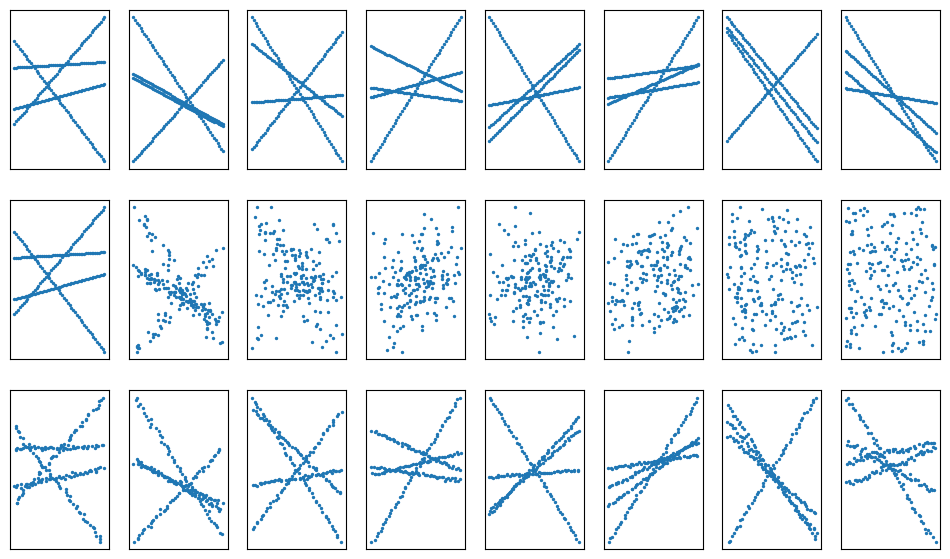

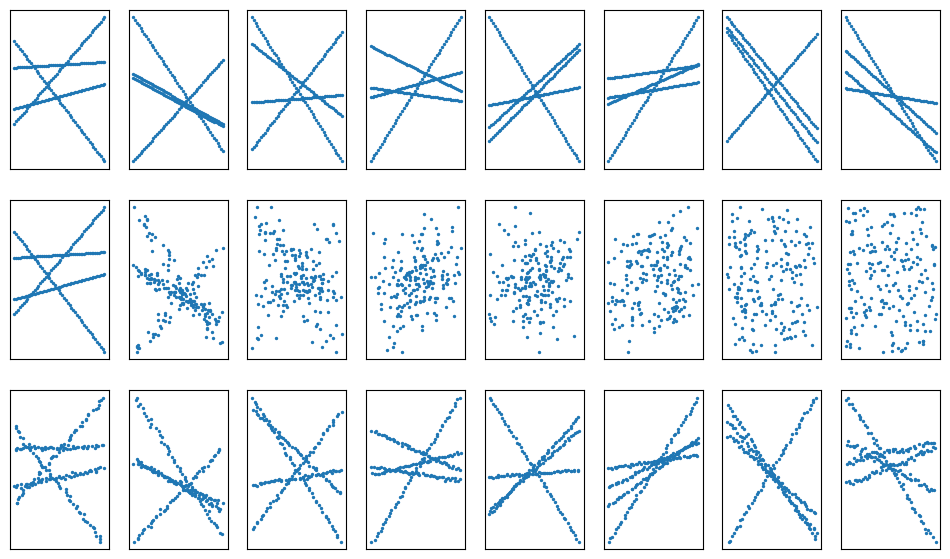

In [41]:
get_generator_figure(net)

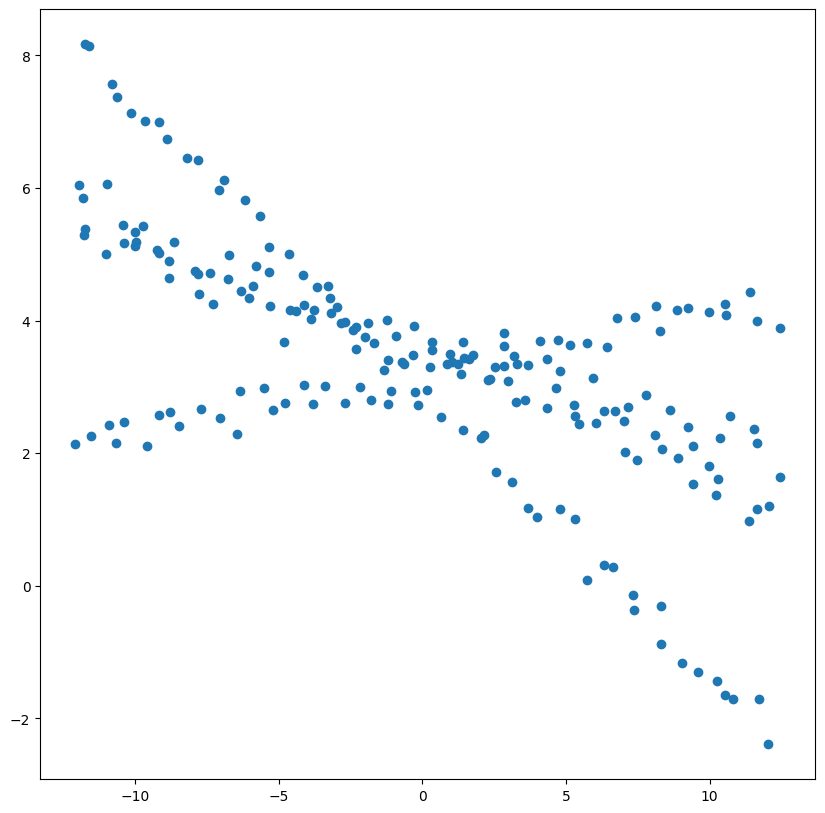

In [ ]:
n_steps = 50
x = torch.rand(1, 2, NUM_POINTS).to(device)

for i in range(n_steps):
    noise_amount = torch.ones((x.shape[0],)).to(device) * (1 - (i / n_steps))  # Starting high going low
    with torch.no_grad():
        pred = net(x)
    mix_factor = 1 / (n_steps - i)
    x = x * (1 - mix_factor) + pred * mix_factor

x = x.squeeze(0).detach().cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(x[0], x[1])